# Stochastic Series Expansion for the Spin-1/2 Heisenberg Chain

## Context and Motivation
The Stochastic Series Expansion (SSE) is a highly efficient Quantum Monte Carlo (QMC) method designed to study the thermodynamic properties of quantum lattice models at finite temperatures. Unlike methods based on the Suzuki-Trotter decomposition, SSE avoids systematic time-discretization errors by directly sampling the Taylor expansion of the partition function. This approach is essential for investigating many-body quantum systems where the Hilbert space grows exponentially, making exact diagonalization computationally impossible for large system sizes. By mapping the quantum problem onto a high-dimensional classical configuration space of operator sequences, SSE provides a powerful tool for obtaining high-precision results for magnetic and thermal observables.

## Theoretical Background
The core of this project is the study of the one-dimensional spin-1/2 Heisenberg model. The system is described by the following Hamiltonian:

$$H = J \sum_{i=1}^{L} \vec{S}_{i} \cdot \vec{S}_{i+1}$$

- where $L$ is the length of the chain and periodic boundary conditions are assumed, such that $L+1 \equiv 1$. Understanding this project requires familiarity with:
- **The Heisenberg Model:** A fundamental paradigm for describing exchange interactions between neighboring spins in magnetic materials.
- **Exchange Coupling ($J$):** The behavior of the system changes drastically depending on the sign of $J$, leading to either an Anti-ferromagnetic ($J=1$) or a Ferromagnetic ($J=-1$) ground state.
- **Magnetic Susceptibility ($\chi$):** A thermodynamic response function that characterizes how the magnetization of the system reacts to an external magnetic field, which we will compute as a function of temperature $T$.
- **Statistical Mechanics of SSE:** The representation of the partition function $Z = \text{Tr}(e^{-\beta H})$ as a summation over operator strings and spin states.

## Objectives of the Project
The primary goal is to develop a robust numerical tool to simulate the magnetic properties of a 1D quantum spin chain. The specific objectives are:

1. **Algorithm Implementation:** Develop and implement the SSE algorithm tailored for the spin-1/2 Heisenberg chain.
2. **Thermodynamic Analysis:** Compute and plot the magnetic susceptibility $\chi(T)$ for both the anti-ferromagnetic ($J=1$) and ferromagnetic ($J=-1$) cases.
3. **Statistical Validation:** Implement rigorous thermalization protocols and estimate error bars by performing independent repetitions of the calculations to ensure the reliability of the results.

In [1642]:
import numpy as np
import matplotlib.pyplot as plt

---

## Theoretical Framework

### Hamiltonian : Factorization into local operators (diagonal and non-diagonal)

We have :
$$\vec{S}_{i} \cdot \vec{S}_{j} = S_i^zS_j^z + \frac 1 2 (S_i^+ S_j^-+ S_i^- S_j^+) \qquad \text{and} \qquad H = J \sum_{i=1}^{L} \vec{S}_{i} \cdot \vec{S}_{i+1}$$

$$\implies H = J \sum_{i=1}^{L} \left(S_i^zS_{i+1}^z + \frac 1 2 (S_i^+ S_{i+1}^-+ S_i^- S_{i+1}^+) + \frac 14 - \frac 14 \right)$$
$$\implies H = J \sum_{i=1}^{L} \left(\left(S_i^zS_{i+1}^z - \frac 14 \right)  + \left(\frac 1 2 (S_i^+ S_{i+1}^-+ S_i^- S_{i+1}^+)\right) + \frac 14 \right) $$

For each link $ b = (i, i+1) $, we define:

- **Diagonal operator** : $H_{1,b} = \frac{1}{4} - S_i^z S_j^z$

- **Non-diagonal operator** : $ H_{2,b} = \frac{1}{2} (S_i^+ S_j^- + S_i^- S_j^+)$

$$\implies H = J \sum_b \left(\left( - H_{1,b}  \right)  + \left(H_{2,b} \right) + \frac 14 \right) $$

For the SSE, we want the Hamiltonian to be a sum of operators with a **negative** sign in front (so that $-H$ in the expansion is positive). But there is a problem: in the expression above, $H_{1,b}$ has a $-$ sign and $H_{2,b}$ has a $+$ sign.

To resolve this, we perform a **spin rotation transformation** (only on a sublattice, since the 1D lattice is bipartite):
* $S_j^+ \to -S_j^+$
* $S_j^- \to -S_j^-$
* $S_j^z \to S_j^z$ (the diagonal term remains unchanged)

This transformation changes the sign of the transverse term ($H_{2,b} \to -H_{2,b}$) without altering the physics of the model (this amounts to redefining the local basis). The Hamiltonian becomes:
$$H = J \sum_b \left( \frac{1}{4} - H_{1,b} - H_{2,b} \right)$$

and we write:

$$ H = -J \sum_b (H_{1,b} + H_{2,b}) + \text{const}$$

In [1643]:
global L, J, beta

L = 100
J = 1.
beta = 0.1

def N_thermalisation(Nt) : # le systeme a besoin de thermaliser avant que l'on calcul des quantitées
  return int(0.2 * Nt)

---

### SSE expansion

The partition function is $Z = Tr(e^{-\beta H})$ and $e^{-\beta H}= \sum_{n=0}^{\infty} \frac{\beta^n}{n!}(-H)^n$. Here we can see why we mentioned $-H$ earlier. 

$$\implies Z = \sum_\alpha \sum_{n=0}^{\infty} \frac{\beta^n}{n!}\langle \alpha|(-H)^n|\alpha\rangle$$

Chaque configuration Monte Carlo est :
- un état de base $|\alpha \rangle$
- une suite d’opérateurs : $S_n = [H_{a_1,b_1}, H_{a_2,b_2}, \dots, H_{a_n,b_n}]$

On a ici une somme qui va jusque $\infty$, c'est impossible a faire numeriquement donc on va appliquer une troncature fixe : $M >> \langle n \rangle$

$$
S_M = [H_{a_1,b_1}, \dots, H_{a_n,b_n}, I, I, \dots]
$$

avec :

* $n$ opérateurs réels
* $M-n$ identités

$$ Z = \sum_\alpha \sum_{n=1}^M \frac{\beta^n}{n!} \langle \alpha | \left( \sum_{b} H_{1,b} H_{2,b} \right)^n | \alpha \rangle$$

$$ = \sum_\alpha \sum_{S_M} \frac{\beta^n}{n!}  \frac{\langle \alpha | \prod_{i=1}^{M} H_{a_i,b_i} | \alpha \rangle}{n \text{ parmis } M} \quad$$

$$\quad = \sum_\alpha \sum_{S_M} \frac{\beta^n (M-n)!}{M!} \langle \alpha | \prod_{i=1}^{M} H_{a_i,b_i} | \alpha \rangle$$

$$ = \sum_\alpha \sum_{S_M} \frac{\beta^n (M-n)!}{M!} \langle \alpha |\alpha(p) \rangle \quad $$

$|\alpha(p) \rangle = \prod_{i=1}^{M} H_{a_i,b_i} | \alpha \rangle$

In [1644]:
global bonds
bonds = [(i, (i+1)%L) for i in range(L)]

M = int(2 * beta * L)

- 0 = identité
- 1 = diagonal (H1)
- 2 = off-diagonal (H2)

In [1645]:
def apply_operator(spins:np.ndarray, op_type_p:int, bond:int):
    i, j = bonds[bond]
    if op_type_p == 0: # identity
        return spins, 1.0
    elif spins[i] != spins[j]:
        #if op_type_p == 1: # diagonal
        #   spins = spins
        if op_type_p == 2: # off-diagonal
            spins[i] *= -1
            spins[j] *= -1
        return spins, 0.5
    
    else : # if we have two spin pointing in the same direction
        return spins, 0.0

## Diagonal Update (Metropolis)

Insertion (identity → diagonal) if antiparalleles spins
$$P_{insert} = \frac{\beta J \langle H_{1,b}\rangle}{M-n} = \frac{\beta J}{M-n} \times \frac 12$$
factor 1/2 a ne pas oublier

remove (diagonal → identity)
$$P_{remove}= \frac{M-n+1}{\beta J \langle H_{1,b}\rangle} = \frac{M-n+1}{\beta J} \times 2$$

On n’insère que des diagonaux parce que ce sont les seuls qui ont une contribution directe au poids dans la base $|\alpha \rangle$.

In [1646]:
def insertion(op_type:np.ndarray, op_bond:np.ndarray, M:int, n:int, p:int, bond:int) ->int:
    prob = (beta * J * L) / (2. * (M - n))
    if np.random.rand() <  min(1., prob):
        op_type[p] = 1
        op_bond[p] = min(1., prob)
        n += 1
    return n

def remove(op_type:np.ndarray, op_bond:np.ndarray, M:int, n:int, p:int) ->int:
    prob = (2. *(M - n + 1)) / (beta * J * L)
    if np.random.rand() < prob:
        op_type[p] = 0
        op_bond[p] = 0
        n -= 1
    return n

def diagonal_update(spins:np.ndarray, op_type:np.ndarray, op_bond:np.ndarray, M:int, n:int) -> int: 
    spins_p = spins.copy()
    for p in range(M):
        op = op_type[p]
        if op == 0 : # identity
            bond = np.random.randint(0, L)
            i,j = bonds[bond]

            if spins_p[i] != spins_p[j]: # insertion possible?
                n = insertion(op_type, op_bond, M, n, p, bond)
        elif op == 1 : # diagonal
            n = remove(op_type, op_bond, M, n, p)
        elif op == 2: # off-diagonal
            i, j = bonds[op_bond[p]]
            spins_p[i] *= -1
            spins_p[j] *= -1
    return n 

In [1647]:
def connexion(site:int, last_leg:int, first_leg:int, link_list:np.ndarray, leg_in:int, leg_out:int):
    """connecter entrée actuelle à sortie précédent
    mettre à jour la sortie"""
    if last_leg[site] == -1: # si première occurrence
        first_leg[site] = leg_in
    else: # si déja vu
        prev = last_leg[site]
        link_list[leg_in] = prev
        link_list[prev] = leg_in

    last_leg[site] = leg_out

def compute_link_list(op_type:np.ndarray, op_bond:np.ndarray, M:int) -> np.ndarray:
    link_list = np.full(4*M, -1, dtype=int)

    last_leg = np.full(L, -1)
    first_leg = np.full(L, -1)

    for p in range(M):
        if op_type[p] == 0: # ignore les identitées car elle ne créent pas de vertex
            continue
        i, j = bonds[op_bond[p]]

        # legs index
        leg0 = 4*p + 0  # i entrée
        leg1 = 4*p + 1  # j entrée
        leg2 = 4*p + 2  # i sortie
        leg3 = 4*p + 3  # j sortie
        
        connexion(i, last_leg, first_leg, link_list, leg_in=leg0, leg_out=leg2)
        connexion(j, last_leg, first_leg, link_list, leg_in=leg1, leg_out=leg3)

    for site in range(L): # fermeture periodique
        if first_leg[site] != -1:
            link_list[first_leg[site]] = last_leg[site]
            link_list[last_leg[site]] = first_leg[site]
    return link_list

In [1648]:
def build_loops(link_list:np.ndarray, M:int) -> list :
    visited = np.zeros(4*M, dtype=bool)
    loops = []

    for start in range(4*M):

        if visited[start] or link_list[start] == -1:
            continue

        current = start
        loop = []

        while True:
            visited[current] = True
            loop.append(current)

            # suivre lien
            current = link_list[current]

            # traverser vertex
            current = current ^ 1

            if current == start:
                break

        loops.append(loop)
    return loops

Une loop flip = changer le type des vertex qu’elle traverse, pas juste les spins :

- parcourir les loops
- avec probabilité 1/2
- échanger diagonal ↔ off-diagonal
- reconstruire les spins, en effet il faut refaire une propagation sur les spins, on reconstruit les spins à partir de la string.

attention Chaque vertex apparaît 4 fois dans la loop Donc on va le flip 4 fois → revenir à l’état initial, il faut donc verifier si ils sont déja apparu

In [1649]:
def loop_update(loops:list, op_bond:np.ndarray, op_type:np.ndarray, spins:np.ndarray) :
    for loop in loops:
        if np.random.rand() < 0.5:
            visited_vertices = set()
            sites_to_flip = set()
            for leg in loop :
                p = leg // 4

                # flip opérateurs
                if p in visited_vertices: # evite les vertex qui apparaisse plusieurs fois
                    continue
                visited_vertices.add(p)
                
                if op_type[p] == 1:
                    op_type[p] = 2
                elif op_type[p] == 2:
                    op_type[p] = 1

                # récupérer site
                i, j = bonds[op_bond[p]]
                if leg % 4 in [0, 2]:
                    site = i
                else:
                    site = j
                sites_to_flip.add(site)

            # flip spins
            for site in sites_to_flip:
                spins[site] *= -1

---

## Mesure

### Energy

- $E = -\frac{\langle n\rangle}\beta + \frac{JL}4$

### Magnetization

- $M = \sum_{i=1}^L s_i$

### Susceptibility

- $\chi = \beta \frac {M^2} L$

Pour notre projet nous calculerons ces valeurs par spin donc elles seront divisé par L

In [1650]:
def compute_energy(n:int)->float:
    return -n / beta + ((J*L)/4) # la constante de décalage

def compute_Magnetization(spins:np.ndarray)->float:
    return np.sum(spins)

def compute_susceptibility(M:float)->float:
    return beta * (M**2) / L

---

## Simulation

In [1651]:
def simulation(N_sweeps:int, M:int) :
    n_list, E_list, M_list, susceptibility_list = [], [], [], [] # liste de mesure

    #initialisation
    spins = np.random.choice([-1, 1], size=L) # Notre système aléatoire
    op_type = np.zeros(M, dtype=int)
    op_bond = np.zeros(M, dtype=int)
    n = np.count_nonzero(op_type) # = M
    
    for t in range(N_sweeps):
        n = diagonal_update(spins, op_type, op_bond, M, n)
        assert n == np.count_nonzero(op_type)
        link_list = compute_link_list(op_type, op_bond, M)
        loops = build_loops(link_list, M)
        loop_update(loops, op_bond, op_type, spins)

        if n > 0.8 * M:
            M_new = int(n * 1.3) # On prend une marge de 30%
            # On étend les tableaux en ajoutant des zéros (Identité) à la fin
            op_type = np.pad(op_type, (0, M_new - M), mode='constant', constant_values=0)
            op_bond = np.pad(op_bond, (0, M_new - M), mode='constant', constant_values=0)
            M = M_new

        Energy_temp = compute_energy(n)
        Magnetization_temp = compute_Magnetization(spins)
        susceptibility_temp = compute_susceptibility(Magnetization_temp)

        n_list.append(n)
        E_list.append(Energy_temp/L)
        M_list.append(Magnetization_temp/L)
        susceptibility_list.append(susceptibility_temp/L)

        if t%(N_sweeps//10) ==0:
            print(t,"/",N_sweeps)
    return n_list, E_list, M_list, susceptibility_list

In [1652]:
N_sweeps = 1000
beta = 100
n_list, E_list, M_list, susceptibility_list = simulation(N_sweeps, M)

N_therm = N_thermalisation(N_sweeps)
E0 = compute_energy(np.mean(n_list[N_therm:]))/L#np.mean(E_list[N_therm:])

0 / 1000
100 / 1000
200 / 1000
300 / 1000
400 / 1000
500 / 1000
600 / 1000
700 / 1000
800 / 1000
900 / 1000


## Plot

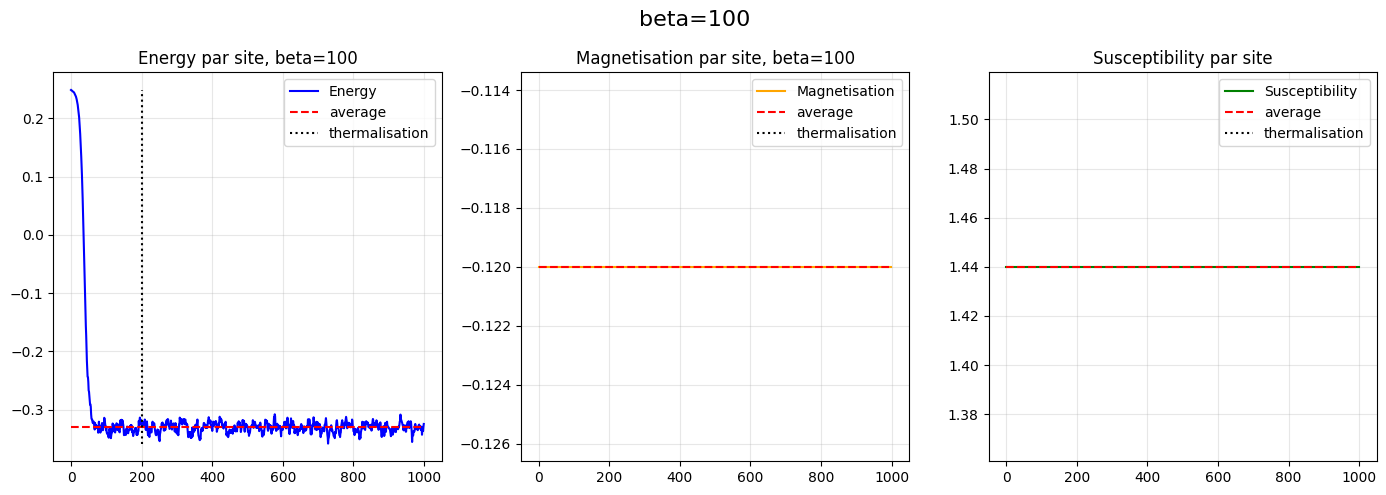

E0 : -0.33055024999999993 ≈? −0.4431


In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

ax1.plot(E_list, label="Energy", color='blue')
ax1.hlines(E0, 0,  N_sweeps, linestyle='--', color='red', label='average')
ax1.vlines(N_therm, min(E_list), max(E_list), linestyle=':', color='black', label='thermalisation')
ax1.set_title(f"Energy par site, beta={beta}")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(M_list, label="Magnetisation", color='orange')
ax2.hlines(np.mean(M_list[N_therm:]), 0,  N_sweeps, linestyle='--', color='red', label='average')
ax2.vlines(N_therm, min(M_list), max(M_list), linestyle=':', color='black', label='thermalisation')
ax2.set_title(f"Magnetisation par site, beta={beta}")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.plot(susceptibility_list, label="Susceptibility", color='green')
ax3.hlines(np.mean(susceptibility_list[N_therm:]), 0,  N_sweeps, linestyle='--', color='red', label='average')
ax3.vlines(N_therm, min(susceptibility_list), max(susceptibility_list), linestyle=':', color='black', label='thermalisation')
ax3.set_title(f"Susceptibility par site")
ax3.legend()
ax3.grid(True, alpha=0.3)

fig.suptitle(f"beta={beta}", fontsize=16)
plt.tight_layout()
plt.show()

if beta >= 100 :
    print(f"E0 : {E0} ≈? -0.4431")
else :
    print(f"E0 : {E0}")